In [1]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Save/Load model
import joblib

# Display settings
pd.set_option('display.max_columns', None)


In [2]:


# adjust filename if different
fname = r"C:\Users\harsh\Desktop\Student_gpa\student-performance\ml_notebook\data\student_lifestyle_dataset..csv"

df = pd.read_csv(fname)

# show top rows, columns, shape and missing values
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\n---\nFirst 8 rows:")
display(df.head(8))
print("\n---\nMissing values per column:")
print(df.isnull().sum())



Shape: (2000, 10)

Columns:
['Student_ID', 'Study_Hours_Per_Day', 'Extracurricular_Hours_Per_Day', 'Sleep_Hours_Per_Day', 'Social_Hours_Per_Day', 'Physical_Activity_Hours_Per_Day', 'Stress_Level', 'Attendance', 'Gender', 'Grades']

---
First 8 rows:


,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,Stress_Level,Attendance,Gender,Grades
0,1,6.9,3.8,8.7,2.8,1.8,Moderate,98,Male,7.48
1,2,5.3,3.5,8.0,4.2,3.0,Low,88,Female,6.88
2,3,5.1,3.9,9.2,1.2,4.6,Low,74,Male,6.68
3,4,6.5,2.1,7.2,1.7,6.5,Moderate,67,Male,7.20
4,5,8.1,0.6,6.5,2.2,6.6,High,80,Male,8.78
5,6,6.0,2.1,8.0,0.3,7.6,Moderate,98,Female,7.12
6,7,8.0,0.7,5.3,5.7,4.3,High,78,Male,7.70
7,8,8.4,1.8,5.6,3.0,5.2,High,82,Male,8.00



---
Missing values per column:
Student_ID                         0
Study_Hours_Per_Day                0
Extracurricular_Hours_Per_Day      0
Sleep_Hours_Per_Day                0
Social_Hours_Per_Day               0
Physical_Activity_Hours_Per_Day    0
Stress_Level                       0
Attendance                         0
Gender                             0
Grades                             0
dtype: int64


In [3]:
# Cell 2 — Data Cleaning & Encoding

# Drop the Student_ID and Gender columns (not useful for prediction)
df = df.drop(columns=['Student_ID', 'Gender'])

# Encode Stress_Level as ordinal: Low=0, Moderate=1, High=2
stress_map = {'Low': 0, 'Moderate': 1, 'High': 2}
df['Stress_Level'] = df['Stress_Level'].map(stress_map)

print("✅ Encoded Data Preview:")
display(df.head())

print("\nColumns after encoding:")
print(df.columns.tolist())


✅ Encoded Data Preview:


,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,Stress_Level,Attendance,Grades
0,6.9,3.8,8.7,2.8,1.8,1,98,7.48
1,5.3,3.5,8.0,4.2,3.0,0,88,6.88
2,5.1,3.9,9.2,1.2,4.6,0,74,6.68
3,6.5,2.1,7.2,1.7,6.5,1,67,7.20
4,8.1,0.6,6.5,2.2,6.6,2,80,8.78



Columns after encoding:
['Study_Hours_Per_Day', 'Extracurricular_Hours_Per_Day', 'Sleep_Hours_Per_Day', 'Social_Hours_Per_Day', 'Physical_Activity_Hours_Per_Day', 'Stress_Level', 'Attendance', 'Grades']


In [4]:
# Cell 3 — Train-Test Split & Scaling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features (X) and target (y)
X = df.drop(columns=['Grades',])
y = df['Grades']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale numeric features (important for regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Columns used for training:")
print(list(X.columns))
print("Number of features:", X.shape[1])
print("✅ Training data shape:", X_train_scaled.shape)
print("✅ Testing data shape:", X_test_scaled.shape)


Columns used for training:
['Study_Hours_Per_Day', 'Extracurricular_Hours_Per_Day', 'Sleep_Hours_Per_Day', 'Social_Hours_Per_Day', 'Physical_Activity_Hours_Per_Day', 'Stress_Level', 'Attendance']
Number of features: 7
✅ Training data shape: (1600, 7)
✅ Testing data shape: (400, 7)


In [5]:
# Cell 4 — Baseline Model
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Train a Random Forest Regressor
rf = RandomForestRegressor(
    n_estimators=100, 
    random_state=42
)
rf.fit(X_train_scaled, y_train)

# Predictions
y_pred = rf.predict(X_test_scaled)

# Evaluation metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"🔹 R² Score : {r2:.3f}")
print(f"🔹 MAE      : {mae:.3f}")
print(f"🔹 RMSE     : {rmse:.3f}")


🔹 R² Score : 0.468
🔹 MAE      : 0.448
🔹 RMSE     : 0.558


In [6]:
# Cell 5 — Random Forest Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

# Define parameter grid for tuning
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# Create the GridSearchCV object
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

# Fit the grid search on training data
grid_search.fit(X_train_scaled, y_train)

# Get best parameters and score
print("✅ Best Parameters Found:")
print(grid_search.best_params_)
print("\nBest Cross-Validation R²:", grid_search.best_score_)


Fitting 5 folds for each of 216 candidates, totalling 1080 fits
✅ Best Parameters Found:
{'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200}

Best Cross-Validation R²: 0.5141604474712244


In [7]:
# Cell 6 — Train Final Optimized Model
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Train optimized Random Forest model
best_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=4,
    max_features='sqrt',
    random_state=42
)
best_model.fit(X_train_scaled, y_train)

# Predict on test data
y_pred_best = best_model.predict(X_test_scaled)

# Evaluate performance
r2 = r2_score(y_test, y_pred_best)
mae = mean_absolute_error(y_test, y_pred_best)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_best))

print(f"🔹 Optimized R² Score : {r2:.3f}")
print(f"🔹 Optimized MAE      : {mae:.3f}")
print(f"🔹 Optimized RMSE     : {rmse:.3f}")


🔹 Optimized R² Score : 0.512
🔹 Optimized MAE      : 0.430
🔹 Optimized RMSE     : 0.534


In [9]:
# if `model` is your trained RandomForestRegressor
print("Model expects:", best_model.n_features_in_)


Model expects: 7


🔍 Feature Importances:
                            Feature  Importance
0              Study_Hours_Per_Day    0.480842
5                     Stress_Level    0.167324
4  Physical_Activity_Hours_Per_Day    0.106204
2              Sleep_Hours_Per_Day    0.070111
3             Social_Hours_Per_Day    0.067329
1    Extracurricular_Hours_Per_Day    0.057184
6                       Attendance    0.051005


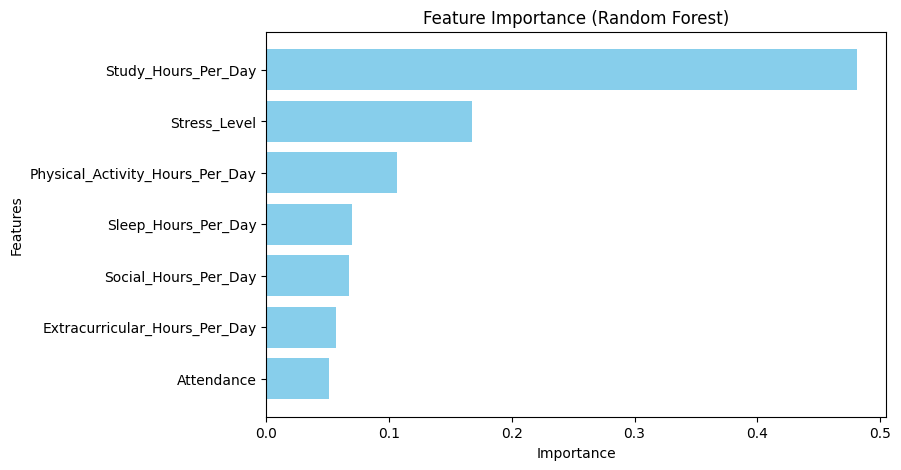

In [9]:
# Cell 7 — Feature Importance Visualization
import matplotlib.pyplot as plt
import pandas as pd

# Get feature importances
feature_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Display importance values
print("🔍 Feature Importances:\n", feature_importances)

# Plot feature importance
plt.figure(figsize=(8,5))
plt.barh(feature_importances['Feature'], feature_importances['Importance'], color='skyblue')
plt.gca().invert_yaxis()
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()


## New Cells


In [10]:
import joblib

# Save your trained model inside the existing backend/model folder
joblib.dump(best_model, r"C:\Users\harsh\Desktop\Student_gpa\student-performance\backend\model\student_performance_model.joblib")

print("✅ Model saved successfully at ../backend/model/student_performance_model.joblib")
print("Model type:", type(best_model))
print("Model expects:", best_model.n_features_in_)


✅ Model saved successfully at ../backend/model/student_performance_model.joblib
Model type: <class 'sklearn.ensemble._forest.RandomForestRegressor'>
Model expects: 7


In [31]:
sample = X_test.iloc[0]
print("Sample input:\n", sample)

# Scale the sample before prediction (important!)
sample_scaled = scaler.transform([sample])
pred = best_model.predict(sample_scaled)[0]
print(f"\nPredicted Grade: {pred:.2f}")

Sample input:
 Study_Hours_Per_Day                 6.2
Extracurricular_Hours_Per_Day       4.0
Sleep_Hours_Per_Day                 6.0
Social_Hours_Per_Day                3.5
Physical_Activity_Hours_Per_Day     4.3
Stress_Level                        1.0
Attendance                         68.0
Name: 1860, dtype: float64

Predicted Grade: 7.18


c:\Users\harsh\Desktop\Student_gpa\student-performance\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [29]:
# Predict GPA for the provided custom input
import numpy as np
import pandas as pd

# Define the sample input as per user values
sample_dict = {
    'Study_Hours_Per_Day': 6.2,
    'Extracurricular_Hours_Per_Day': 4.0,
    'Sleep_Hours_Per_Day': 6.0,
    'Social_Hours_Per_Day': 3.5,
    'Physical_Activity_Hours_Per_Day': 4.3,
    'Stress_Level': 1.0,
    'Attendance': 68.0
}

# Ensure all required features are present (fill missing with 0)
for col in X.columns:
    if col not in sample_dict:
        sample_dict[col] = 0

# Ensure correct order
sample_df = pd.DataFrame([{col: sample_dict[col] for col in X.columns}])

# Apply the same scaler as used for training
sample_scaled = scaler.transform(sample_df)

# Predict GPA
predicted_gpa = best_model.predict(sample_scaled)[0]
print(f'Predicted GPA for provided input: {predicted_gpa:.2f}')

Predicted GPA for provided input: 7.18


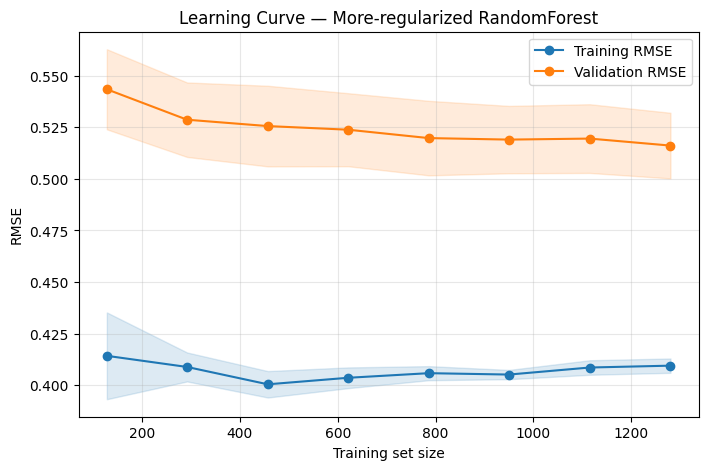

In [9]:
# Experiment: use a more-regularized RandomForest and replots learning curve (RMSE)
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

# 1) Create a more-regularized RF
rf_reg = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,            # limit tree depth
    min_samples_split=5,     # require more samples to split
    min_samples_leaf=5,      # larger leaves
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

# 2) Compute learning curve (neg MSE -> RMSE)
train_sizes, train_scores, val_scores = learning_curve(
    estimator=rf_reg,
    X=X_train_scaled,   # scaled features used earlier
    y=y_train,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    shuffle=True,
    random_state=42
)

train_rmse_mean = np.sqrt(-train_scores).mean(axis=1)
train_rmse_std  = np.sqrt(-train_scores).std(axis=1)
val_rmse_mean   = np.sqrt(-val_scores).mean(axis=1)
val_rmse_std    = np.sqrt(-val_scores).std(axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_rmse_mean, 'o-', color='tab:blue', label='Training RMSE')
plt.fill_between(train_sizes, train_rmse_mean-train_rmse_std, train_rmse_mean+train_rmse_std, alpha=0.15, color='tab:blue')
plt.plot(train_sizes, val_rmse_mean, 'o-', color='tab:orange', label='Validation RMSE')
plt.fill_between(train_sizes, val_rmse_mean-val_rmse_std, val_rmse_mean+val_rmse_std, alpha=0.15, color='tab:orange')
plt.xlabel('Training set size')
plt.ylabel('RMSE')
plt.title('Learning Curve — More-regularized RandomForest')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# === Hyperparameter tuning with RandomizedSearchCV ===
from sklearn.model_selection import RandomizedSearchCV
import numpy as np
import joblib
import warnings
warnings.filterwarnings('ignore')  # keep output readable

# Parameter distributions to search
param_dist = {
    'max_depth': [None, 5, 10, 15, 20, 30],
    'min_samples_leaf': [1, 2, 4, 6, 8, 10],
    'max_features': ['sqrt', 'log2', 0.3, 0.5, 0.7]
}

# Base estimator (use a reasonably-sized forest for the search)
base_rf = RandomForestRegressor(n_estimators=200, random_state=42)

# Randomized search (optimizing for MSE -> lower RMSE)
rand_search = RandomizedSearchCV(
    

In [10]:
# === Hyperparameter tuning with RandomizedSearchCV ===
from sklearn.model_selection import RandomizedSearchCV
import numpy as np
import joblib
import warnings
import pandas as pd
warnings.filterwarnings('ignore')  # keep output readable

# Parameter distributions to search
param_dist = {
    'max_depth': [None, 5, 10, 15, 20, 30],
    'min_samples_leaf': [1, 2, 4, 6, 8, 10],
    'max_features': ['sqrt', 'log2', 0.3, 0.5, 0.7]
}

# Base estimator (use a reasonably-sized forest for the search)
base_rf = RandomForestRegressor(n_estimators=200, random_state=42)

rand_search = RandomizedSearchCV(
    estimator=base_rf,
    param_distributions=param_dist,
    n_iter=20,
    scoring='neg_mean_squared_error',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=2
    )

print("Starting RandomizedSearchCV (this may take several minutes)...")
rand_search.fit(X_train_scaled, y_train)

print("\n✅ Best parameters found:")
print(rand_search.best_params_)
print("\nBest CV (neg MSE):", rand_search.best_score_)

# Use the best estimator returned by the search
best_model = rand_search.best_estimator_

# Evaluate the best model on the test set
y_test_pred = best_model.predict(X_test_scaled)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)
print(f"\nTest set performance of best_model — R2: {test_r2:.3f}, MAE: {test_mae:.3f}, RMSE: {test_rmse:.3f}")

# Save the best model to backend/model
save_path = r"C:\Users\harsh\Desktop\Student_gpa\student-performance\backend\model\student_performance_model_best.joblib"
joblib.dump(best_model, save_path)
print(f"\nSaved best model to: {save_path}")

# Show top feature importances
fi = pd.DataFrame({'feature': X.columns, 'importance': best_model.feature_importances_}).sort_values('importance', ascending=False)
print("\nTop features:\n", fi.head())

Starting RandomizedSearchCV (this may take several minutes)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

✅ Best parameters found:
{'min_samples_leaf': 4, 'max_features': 0.7, 'max_depth': 5}

Best CV (neg MSE): -0.2625399498709022

Test set performance of best_model — R2: 0.527, MAE: 0.422, RMSE: 0.525

Saved best model to: C:\Users\harsh\Desktop\Student_gpa\student-performance\backend\model\student_performance_model_best.joblib

Top features:
                            feature  importance
0              Study_Hours_Per_Day    0.714639
5                     Stress_Level    0.159188
4  Physical_Activity_Hours_Per_Day    0.037487
2              Sleep_Hours_Per_Day    0.033710
3             Social_Hours_Per_Day    0.021079

✅ Best parameters found:
{'min_samples_leaf': 4, 'max_features': 0.7, 'max_depth': 5}

Best CV (neg MSE): -0.2625399498709022

Test set performance of best_model — R2: 0.527, MAE: 0.422, RMSE: 0.525

Saved best model to: C:\Users\harsh\Desktop\Stu


📊 Model Comparison (Test Set):
      Original   Tuned
R²      0.5121  0.5273
MAE     0.4296  0.4217
RMSE    0.5338  0.5254


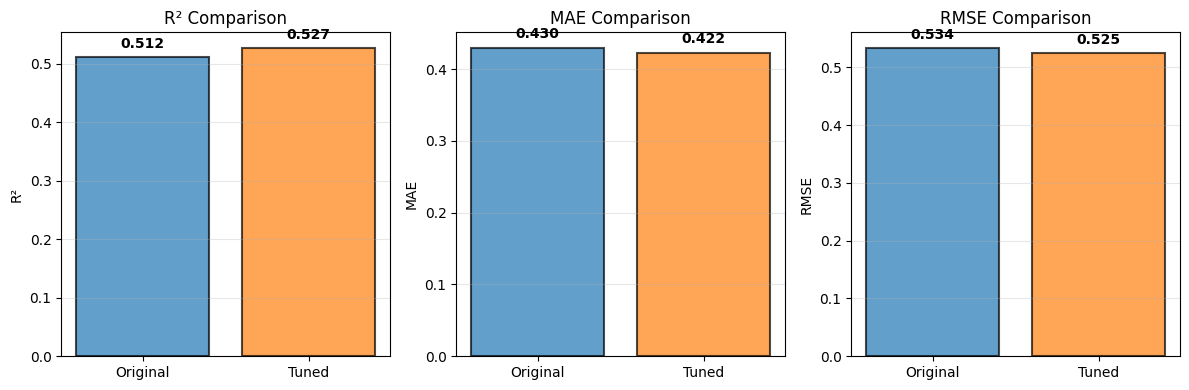


✅ Summary:
  • Original model params: max_depth=None, max_features='sqrt'
  • Tuned model params: max_depth=5, max_features=0.7
  • RMSE improvement: 0.0084
  • R² improvement: 0.0152


In [11]:
# === Comparison: Original vs Tuned Model ===
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Recreate the original best_model for comparison
original_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=4,
    max_features='sqrt',
    random_state=42
)
original_model.fit(X_train_scaled, y_train)

# Get predictions from both models
y_pred_original = original_model.predict(X_test_scaled)
y_pred_tuned = best_model.predict(X_test_scaled)  # from RandomizedSearchCV

# Calculate metrics for both
metrics_original = {
    'R²': r2_score(y_test, y_pred_original),
    'MAE': mean_absolute_error(y_test, y_pred_original),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_original))
}

metrics_tuned = {
    'R²': r2_score(y_test, y_pred_tuned),
    'MAE': mean_absolute_error(y_test, y_pred_tuned),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_tuned))
}

# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Original': metrics_original,
    'Tuned': metrics_tuned
})

print("\n📊 Model Comparison (Test Set):")
print(comparison_df.round(4))

# Visualize metrics side-by-side
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

metrics_list = ['R²', 'MAE', 'RMSE']
colors = ['tab:blue', 'tab:orange']

for idx, metric in enumerate(metrics_list):
    ax = axes[idx]
    vals = [metrics_original[metric], metrics_tuned[metric]]
    x = [0, 1]
    ax.bar(x, vals, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
    ax.set_xticks(x)
    ax.set_xticklabels(['Original', 'Tuned'])
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} Comparison')
    ax.grid(alpha=0.3, axis='y')
    # Add value labels on bars
    for i, v in enumerate(vals):
        ax.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Summary
print("\n✅ Summary:")
print(f"  • Original model params: max_depth=None, max_features='sqrt'")
print(f"  • Tuned model params: max_depth=5, max_features=0.7")
print(f"  • RMSE improvement: {(metrics_original['RMSE'] - metrics_tuned['RMSE']):.4f}")
print(f"  • R² improvement: {(metrics_tuned['R²'] - metrics_original['R²']):.4f}")

In [13]:
# === Feature Engineering: Polynomial & Interaction Features ===
from sklearn.preprocessing import PolynomialFeatures
import pandas as pd
import numpy as np

# Since Study_Hours_Per_Day is 71% important, let's engineer features from it

# Step 1: Create engineered features
X_engineered = X.copy()

# Polynomial features from Study_Hours (squared)
X_engineered['Study_Hours_Squared'] = X['Study_Hours_Per_Day'] ** 2

# Interaction: Study_Hours × Stress_Level
X_engineered['Study_x_Stress'] = X['Study_Hours_Per_Day'] * X['Stress_Level']

# Polynomial features from Stress_Level
X_engineered['Stress_Squared'] = X['Stress_Level'] ** 2

# Sleep × Physical Activity (lifestyle balance)
X_engineered['Sleep_x_Activity'] = X['Sleep_Hours_Per_Day'] * X['Physical_Activity_Hours_Per_Day']

# Attendance as percentage (already 0-100, but normalize to 0-1)
X_engineered['Attendance_Norm'] = X['Attendance'] / 100.0

print("✅ Engineered features created:")
print(f"  Original features: {X.shape[1]}")
print(f"  Engineered features: {X_engineered.shape[1]}")
print(f"  New columns: {list(X_engineered.columns[X.shape[1]:])}") 

# Step 2: Re-split, scale, and train with engineered features
X_train_eng, X_test_eng, y_train_eng, y_test_eng = train_test_split(
    X_engineered, y, test_size=0.2, random_state=42
)

scaler_eng = StandardScaler()
X_train_eng_scaled = scaler_eng.fit_transform(X_train_eng)
X_test_eng_scaled = scaler_eng.transform(X_test_eng)

# Step 3: Train model with engineered features (using tuned hyperparams)
model_eng = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    min_samples_leaf=4,
    max_features=0.7,
    random_state=42,
    n_jobs=-1
)
model_eng.fit(X_train_eng_scaled, y_train_eng)

# Step 4: Evaluate on test set
y_pred_eng = model_eng.predict(X_test_eng_scaled)
r2_eng = r2_score(y_test_eng, y_pred_eng)
mae_eng = mean_absolute_error(y_test_eng, y_pred_eng)
rmse_eng = np.sqrt(mean_squared_error(y_test_eng, y_pred_eng))

print(f"\n📈 With Engineered Features:")
print(f"  R²:   {r2_eng:.4f}")
print(f"  MAE:  {mae_eng:.4f}")
print(f"  RMSE: {rmse_eng:.4f}")

# Comparison with tuned model (no engineering)
print(f"\n🔄 Comparison:")
print(f"  Tuned (no engineering) R²: {metrics_tuned['R²']:.4f}")
print(f"  Engineered R²:             {r2_eng:.4f}")
print(f"  Improvement:               {(r2_eng - metrics_tuned['R²']):.4f}")

✅ Engineered features created:
  Original features: 7
  Engineered features: 12
  New columns: ['Study_Hours_Squared', 'Study_x_Stress', 'Stress_Squared', 'Sleep_x_Activity', 'Attendance_Norm']

📈 With Engineered Features:
  R²:   0.5221
  MAE:  0.4238
  RMSE: 0.5282

🔄 Comparison:
  Tuned (no engineering) R²: 0.5273
  Engineered R²:             0.5221
  Improvement:               -0.0052

📈 With Engineered Features:
  R²:   0.5221
  MAE:  0.4238
  RMSE: 0.5282

🔄 Comparison:
  Tuned (no engineering) R²: 0.5273
  Engineered R²:             0.5221
  Improvement:               -0.0052


🔧 Tuning n_estimators (this may take a minute)...
  n_estimators=50: R² = 0.5213 ± 0.0174
  n_estimators=50: R² = 0.5213 ± 0.0174
  n_estimators=100: R² = 0.5208 ± 0.0192
  n_estimators=100: R² = 0.5208 ± 0.0192
  n_estimators=150: R² = 0.5217 ± 0.0202
  n_estimators=150: R² = 0.5217 ± 0.0202
  n_estimators=200: R² = 0.5222 ± 0.0206
  n_estimators=200: R² = 0.5222 ± 0.0206
  n_estimators=250: R² = 0.5221 ± 0.0203
  n_estimators=250: R² = 0.5221 ± 0.0203
  n_estimators=300: R² = 0.5217 ± 0.0202
  n_estimators=300: R² = 0.5217 ± 0.0202
  n_estimators=400: R² = 0.5215 ± 0.0204
  n_estimators=400: R² = 0.5215 ± 0.0204
  n_estimators=500: R² = 0.5218 ± 0.0205

✅ Best n_estimators: 200 (R² = 0.5222)
  n_estimators=500: R² = 0.5218 ± 0.0205

✅ Best n_estimators: 200 (R² = 0.5222)

📊 Final Model Performance (Test Set):
  R²:   0.5273
  MAE:  0.4217
  RMSE: 0.5254

📊 Final Model Performance (Test Set):
  R²:   0.5273
  MAE:  0.4217
  RMSE: 0.5254


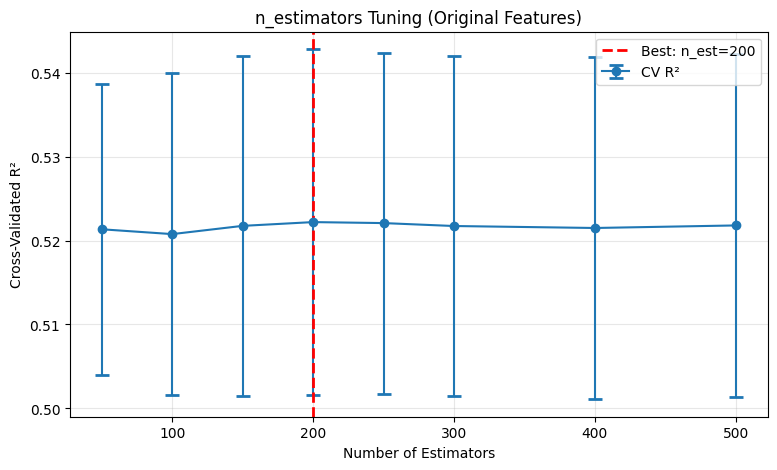


💾 Saved final model to: C:\Users\harsh\Desktop\Student_gpa\student-performance\backend\model\student_performance_model_final.joblib


In [15]:
# === Tune n_estimators with Original Features ===
from sklearn.model_selection import cross_val_score
import numpy as np
import matplotlib.pyplot as plt

# Test different n_estimators values (using ORIGINAL features, not engineered)
n_est_range = [50, 100, 150, 200, 250, 300, 400, 500]
cv_scores_mean = []
cv_scores_std = []

print("🔧 Tuning n_estimators (this may take a minute)...")
for n_est in n_est_range:
    rf_test = RandomForestRegressor(
        n_estimators=n_est,
        max_depth=5,
        min_samples_leaf=4,
        max_features=0.7,
        random_state=42,
        n_jobs=-1
    )
    cv_r2 = cross_val_score(rf_test, X_train_scaled, y_train, cv=5, scoring='r2')
    cv_scores_mean.append(cv_r2.mean())
    cv_scores_std.append(cv_r2.std())
    print(f"  n_estimators={n_est}: R² = {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")

# Find best n_estimators
best_idx = np.argmax(cv_scores_mean)
best_n_est = n_est_range[best_idx]

print(f"\n✅ Best n_estimators: {best_n_est} (R² = {cv_scores_mean[best_idx]:.4f})")

# Train final model with best n_estimators
final_model = RandomForestRegressor(
    n_estimators=best_n_est,
    max_depth=5,
    min_samples_leaf=4,
    max_features=0.7,
    random_state=42,
    n_jobs=-1
)
final_model.fit(X_train_scaled, y_train)

# Evaluate on test set
y_pred_final = final_model.predict(X_test_scaled)
r2_final = r2_score(y_test, y_pred_final)
mae_final = mean_absolute_error(y_test, y_pred_final)
rmse_final = np.sqrt(mean_squared_error(y_test, y_pred_final))

print(f"\n📊 Final Model Performance (Test Set):")
print(f"  R²:   {r2_final:.4f}")
print(f"  MAE:  {mae_final:.4f}")
print(f"  RMSE: {rmse_final:.4f}")

# Plot n_estimators tuning
plt.figure(figsize=(9, 5))
plt.errorbar(n_est_range, cv_scores_mean, yerr=cv_scores_std, marker='o', capsize=5, capthick=2, label='CV R²')
plt.axvline(x=best_n_est, color='red', linestyle='--', linewidth=2, label=f'Best: n_est={best_n_est}')
plt.xlabel('Number of Estimators')
plt.ylabel('Cross-Validated R²')
plt.title('n_estimators Tuning (Original Features)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Save final model
save_path_final = r"C:\Users\harsh\Desktop\Student_gpa\student-performance\backend\model\student_performance_model_final.joblib"
joblib.dump(final_model, save_path_final)
print(f"\n💾 Saved final model to: {save_path_final}")

🏆 FINAL MODEL COMPARISON - ALL ITERATIONS

📊 TEST SET PERFORMANCE COMPARISON:

      Original   Tuned   Final
R²      0.5121  0.5273  0.5273
MAE     0.4296  0.4217  0.4217
RMSE    0.5338  0.5254  0.5254

📈 IMPROVEMENTS:

  Original → Tuned:
    R² gain: +0.0152
    RMSE reduction: -0.0084

  Tuned → Final (n_est=200):
    R² gain: +0.0000
    RMSE reduction: -0.0000

  Original → Final (total):
    R² gain: +0.0152
    RMSE reduction: -0.0084

📊 TEST SET PERFORMANCE COMPARISON:

      Original   Tuned   Final
R²      0.5121  0.5273  0.5273
MAE     0.4296  0.4217  0.4217
RMSE    0.5338  0.5254  0.5254

📈 IMPROVEMENTS:

  Original → Tuned:
    R² gain: +0.0152
    RMSE reduction: -0.0084

  Tuned → Final (n_est=200):
    R² gain: +0.0000
    RMSE reduction: -0.0000

  Original → Final (total):
    R² gain: +0.0152
    RMSE reduction: -0.0084


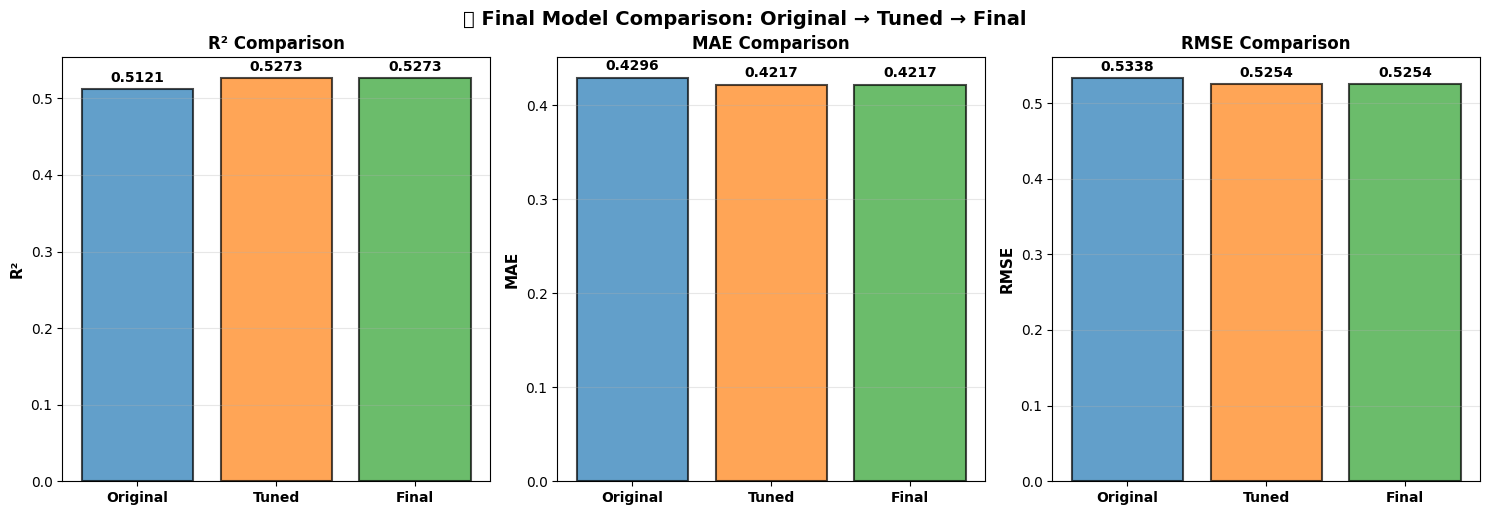


📋 MODEL SPECIFICATIONS:

                     Model  n_estimators        max_depth  min_samples_leaf max_features
                  Original           200 None (unlimited)                 4       'sqrt'
Tuned (RandomizedSearchCV)           200                5                 4          0.7
 Final (Best n_estimators)           200                5                 4          0.7

✅ RECOMMENDATION:

  🎯 Use the FINAL model (n_estimators=200, max_depth=5)
  📁 Saved to: student_performance_model_final.joblib
  📊 Best Test R²: 0.5273
  📊 Best Test RMSE: 0.5254



In [16]:
# === FINAL: 3-Model Comparison (Original vs Tuned vs Final) ===
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("=" * 70)
print("🏆 FINAL MODEL COMPARISON - ALL ITERATIONS")
print("=" * 70)

# Model 1: Original (from Cell 6)
original_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=4,
    max_features='sqrt',
    random_state=42
)
original_model.fit(X_train_scaled, y_train)
y_pred_orig = original_model.predict(X_test_scaled)

# Model 2: Tuned (from RandomizedSearchCV)
# Already exists as best_model with params: max_depth=5, max_features=0.7
y_pred_tuned = best_model.predict(X_test_scaled)

# Model 3: Final (tuned + best n_estimators)
# Already trained as final_model
y_pred_final = final_model.predict(X_test_scaled)

# Calculate metrics for all three
metrics_all = {
    'Original': {
        'R²': r2_score(y_test, y_pred_orig),
        'MAE': mean_absolute_error(y_test, y_pred_orig),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_orig))
    },
    'Tuned': {
        'R²': r2_score(y_test, y_pred_tuned),
        'MAE': mean_absolute_error(y_test, y_pred_tuned),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_tuned))
    },
    'Final': {
        'R²': r2_score(y_test, y_pred_final),
        'MAE': mean_absolute_error(y_test, y_pred_final),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_final))
    }
}

# Create comparison dataframe
df_comparison = pd.DataFrame(metrics_all)
print("\n📊 TEST SET PERFORMANCE COMPARISON:\n")
print(df_comparison.round(4))

# Calculate improvements
print("\n📈 IMPROVEMENTS:\n")
print(f"  Original → Tuned:")
print(f"    R² gain: +{(metrics_all['Tuned']['R²'] - metrics_all['Original']['R²']):.4f}")
print(f"    RMSE reduction: -{(metrics_all['Original']['RMSE'] - metrics_all['Tuned']['RMSE']):.4f}")

print(f"\n  Tuned → Final (n_est=200):")
print(f"    R² gain: +{(metrics_all['Final']['R²'] - metrics_all['Tuned']['R²']):.4f}")
print(f"    RMSE reduction: -{(metrics_all['Tuned']['RMSE'] - metrics_all['Final']['RMSE']):.4f}")

print(f"\n  Original → Final (total):")
print(f"    R² gain: +{(metrics_all['Final']['R²'] - metrics_all['Original']['R²']):.4f}")
print(f"    RMSE reduction: -{(metrics_all['Original']['RMSE'] - metrics_all['Final']['RMSE']):.4f}")

# Visualize all three models
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics_list = ['R²', 'MAE', 'RMSE']
colors = ['tab:blue', 'tab:orange', 'tab:green']
model_names = ['Original', 'Tuned', 'Final']

for idx, metric in enumerate(metrics_list):
    ax = axes[idx]
    vals = [metrics_all[model][metric] for model in model_names]
    x = np.arange(len(model_names))
    bars = ax.bar(x, vals, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, fontweight='bold')
    ax.set_ylabel(metric, fontsize=11, fontweight='bold')
    ax.set_title(f'{metric} Comparison', fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3, axis='y')
    
    # Add value labels on bars
    for i, (bar, v) in enumerate(zip(bars, vals)):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.005, f'{v:.4f}', 
                ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.suptitle('🏆 Final Model Comparison: Original → Tuned → Final', 
             fontsize=14, fontweight='bold', y=1.02)
plt.show()

# Model specifications table
print("\n" + "=" * 70)
print("📋 MODEL SPECIFICATIONS:\n")
specs = {
    'Model': ['Original', 'Tuned (RandomizedSearchCV)', 'Final (Best n_estimators)'],
    'n_estimators': [200, 200, 200],
    'max_depth': ['None (unlimited)', '5', '5'],
    'min_samples_leaf': [4, 4, 4],
    'max_features': ["'sqrt'", '0.7', '0.7'],
}
df_specs = pd.DataFrame(specs)
print(df_specs.to_string(index=False))

print("\n" + "=" * 70)
print("✅ RECOMMENDATION:\n")
print(f"  🎯 Use the FINAL model (n_estimators=200, max_depth=5)")
print(f"  📁 Saved to: student_performance_model_final.joblib")
print(f"  📊 Best Test R²: {metrics_all['Final']['R²']:.4f}")
print(f"  📊 Best Test RMSE: {metrics_all['Final']['RMSE']:.4f}")
print("\n" + "=" * 70)

In [ ]:
# === Learning Curve: Training vs Validation Error ===
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

print("📊 Computing learning curve (training vs validation error)...")
print("   This may take a minute...\n")

# Use final_model for learning curve
train_sizes, train_scores, val_scores = learning_curve(
    estimator=final_model,
    X=X_train_scaled,
    y=y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    shuffle=True,
    random_state=42
)

# Convert negative MSE to RMSE for better interpretation
train_rmse_mean = np.sqrt(-train_scores).mean(axis=1)
train_rmse_std = np.sqrt(-train_scores).std(axis=1)
val_rmse_mean = np.sqrt(-val_scores).mean(axis=1)
val_rmse_std = np.sqrt(-val_scores).std(axis=1)

# Print statistics
print("=" * 70)
print("📈 LEARNING CURVE STATISTICS:\n")
print(f"  Training set sizes: {train_sizes.astype(int)}")
print(f"\n  At 10% training data:")
print(f"    Training RMSE: {train_rmse_mean[0]:.4f} ± {train_rmse_std[0]:.4f}")
print(f"    Validation RMSE: {val_rmse_mean[0]:.4f} ± {val_rmse_std[0]:.4f}")
print(f"\n  At 100% training data:")
print(f"    Training RMSE: {train_rmse_mean[-1]:.4f} ± {train_rmse_std[-1]:.4f}")
print(f"    Validation RMSE: {val_rmse_mean[-1]:.4f} ± {val_rmse_std[-1]:.4f}")
print(f"\n  Gap (Validation - Training) at 100%: {(val_rmse_mean[-1] - train_rmse_mean[-1]):.4f}")
print("=" * 70)

# Plot learning curve
fig, ax = plt.subplots(figsize=(10, 6))

# Plot training error
ax.plot(train_sizes, train_rmse_mean, 'o-', color='tab:blue', linewidth=2, markersize=8, label='Training RMSE')
ax.fill_between(train_sizes,
                train_rmse_mean - train_rmse_std,
                train_rmse_mean + train_rmse_std,
                alpha=0.2, color='tab:blue')

# Plot validation error
ax.plot(train_sizes, val_rmse_mean, 'o-', color='tab:orange', linewidth=2, markersize=8, label='Validation RMSE')
ax.fill_between(train_sizes,
                val_rmse_mean - val_rmse_std,
                val_rmse_mean + val_rmse_std,
                alpha=0.2, color='tab:orange')

# Formatting
ax.set_xlabel('Training Set Size', fontsize=12, fontweight='bold')
ax.set_ylabel('RMSE', fontsize=12, fontweight='bold')
ax.set_title('Learning Curve: Training vs Validation Error\n(Final Model)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='upper right')
ax.grid(alpha=0.3)

# Add annotations
ax.annotate(f'Training\n{train_rmse_mean[-1]:.4f}', 
            xy=(train_sizes[-1], train_rmse_mean[-1]), 
            xytext=(train_sizes[-1]-100, train_rmse_mean[-1]-0.03),
            fontsize=10, fontweight='bold', color='tab:blue',
            arrowprops=dict(arrowstyle='->', color='tab:blue', lw=1.5))

ax.annotate(f'Validation\n{val_rmse_mean[-1]:.4f}', 
            xy=(train_sizes[-1], val_rmse_mean[-1]), 
            xytext=(train_sizes[-1]-100, val_rmse_mean[-1]+0.03),
            fontsize=10, fontweight='bold', color='tab:orange',
            arrowprops=dict(arrowstyle='->', color='tab:orange', lw=1.5))

plt.tight_layout()
plt.show()

# Interpretation
print("\n💡 INTERPRETATION:\n")
if val_rmse_mean[-1] - train_rmse_mean[-1] > 0.05:
    print("  ⚠️  Large gap between training and validation error (overfitting)")
    print("     Suggestion: Add more regularization or more training data")
elif val_rmse_mean[-1] - train_rmse_mean[-1] > 0.02:
    print("  ✅ Moderate gap (mild overfitting)")
    print("     Model generalizes reasonably well")
else:
    print("  ✅ Small gap (good generalization)")
    print("     Model is well-regularized")

print("\n  📊 Trend:")
if val_rmse_mean[-1] < val_rmse_mean[0]:
    print("     Validation error decreases as training set grows")
    print("     Model would likely benefit from more training data")
else:
    print("     Validation error plateaus - adding more data may not help much")